## IMPORTS

In [9]:
!pip install seaborn

In [10]:
import pandas as pd
import numpy as np
import pytz
from datetime import datetime, timedelta
import plotly.graph_objects as go
from scipy.stats import linregress
import warnings
warnings.filterwarnings('ignore')



ModuleNotFoundError: No module named 'plotly'

In [11]:
# ── Change these two lines only ───────────────────────────────────────────────
START_DATE = '2022-01-01'
END_DATE   = '2026-01-30'


## DATA

In [12]:
_chunks = []
for _chunk in pd.read_csv(
    '/Users/x/Desktop/algo_project/database/ohlcv_data/XAUUSD_COMPLETE.csv',
    parse_dates=['timestamp'], chunksize=50_000
):
    _chunk = _chunk.set_index('timestamp').sort_index()
    _slice = _chunk.loc[START_DATE:END_DATE]
    if len(_slice):
        _chunks.append(_slice)
    if _chunk.index[-1] > pd.Timestamp(END_DATE):
        break

data_xauusd_5 = pd.concat(_chunks).sort_index() if _chunks else pd.DataFrame()
data_gcvol_5  = pd.read_csv('/Users/x/Desktop/algo_project/database/ohlcv_data/GC_FUTURES_1MIN.csv')

print(f"XAUUSD loaded: {len(data_xauusd_5):,} rows  ({data_xauusd_5.index[0].date()} → {data_xauusd_5.index[-1].date()})")


XAUUSD loaded: 1,446,460 rows  (2022-01-02 → 2026-01-30)


## SESSIONS

#### DEFINITIONS

Sessions are defined in UTC and split by DST. Europe/London timezone is used as the DST reference — Poland (CEST/CET) and UK (BST/GMT) shift clocks on the same day, so London always opens at 09:00 Polish time year-round.

Sydney session is excluded. For XAUUSD, Sydney hours carry very thin volume and frequently produce wicks that create false session highs/lows. The meaningful pre-London range forms during Tokyo hours only.

---

**Summer (BST/CEST active — last Sunday of March to last Sunday of October)**

| Session | UTC | Amsterdam(CEST, UTC+2) |
|---|---|---|
| Asian (Tokyo) | 00:00 - 07:00 | 02:00 - 09:00 |
| London | 07:00 - 16:00 | 09:00 - 18:00 |
| London/NY overlap | 13:00 - 16:00 | 15:00 - 18:00 |
| New York | 13:00 - 21:00 | 15:00 - 23:00 |

**Winter (GMT/CET active — last Sunday of October to last Sunday of March)**

| Session | UTC | Amsterdam(CET, UTC+1) |
|---|---|---|
| Asian (Tokyo) | 00:00 - 08:00 | 01:00 - 09:00 |
| London | 08:00 - 17:00 | 09:00 - 18:00 |
| London/NY overlap | 14:00 - 17:00 | 15:00 - 18:00 |
| New York | 14:00 - 22:00 | 15:00 - 23:00 |

---

The Asian session high, low, and close position metrics used in the ORB strategy are computed from Tokyo session bars only (00:00-07:00 UTC summer / 00:00-08:00 UTC winter). The close position is measured at the last bar before London open, not at a fixed 08:00 UTC timestamp.

In [13]:
def is_summer(date):
    """True if date falls in European summer time (BST/CEST)."""
    tz = pytz.timezone('Europe/London')
    dt = tz.localize(datetime(date.year, date.month, date.day))
    return bool(dt.dst())

# Session definitions in UTC hours
# Each session is (start_hour, end_hour) — end_hour is exclusive
# Sydney spans midnight so it's handled separately as (22, 24) on prev day + (0, end)

def get_sessions(date):
    """
    Returns UTC hour boundaries for each session on a given date.
    Accounts for DST — London/NY shift by 1 hour between summer and winter.
    
    Asian session = Tokyo only (00:00-07:00 UTC summer / 00:00-08:00 UTC winter)
    Sydney excluded — too thin for XAUUSD, creates false highs/lows.
    """
    summer = is_summer(date)
    return {
        'asian':  (0,  7  if summer else 8),   # Tokyo session
        'london': (7  if summer else 8,
                   16 if summer else 17),       # London session
        'ny':     (13 if summer else 14,
                   21 if summer else 22),       # New York session (post-lunch)
        'overlap':(13 if summer else 14,        # London/NY overlap
                   16 if summer else 17),
    }

# Quick check
for label, d in [('Summer', datetime(2025, 6, 15)), ('Winter', datetime(2025, 1, 15))]:
    s = get_sessions(d)
    print(f"{label} ({d.strftime('%b %d')}):")
    for name, (start, end) in s.items():
        print(f"  {name:<8} {start:02d}:00 → {end:02d}:00 UTC")
    print()


Summer (Jun 15):
  asian    00:00 → 07:00 UTC
  london   07:00 → 16:00 UTC
  ny       13:00 → 21:00 UTC
  overlap  13:00 → 16:00 UTC

Winter (Jan 15):
  asian    00:00 → 08:00 UTC
  london   08:00 → 17:00 UTC
  ny       14:00 → 22:00 UTC
  overlap  14:00 → 17:00 UTC



In [14]:
def tag_sessions(df):
    """
    Adds a 'session' column to a 1-min OHLCV dataframe.
    Values: 'asian', 'london', 'ny', 'overlap', 'off'
    """
    df = df.copy()
    df.index = pd.to_datetime(df.index)

    def get_session_label(ts):
        sessions = get_sessions(ts.date())
        h = ts.hour
        if sessions['overlap'][0] <= h < sessions['overlap'][1]:
            return 'overlap'
        if sessions['asian'][0] <= h < sessions['asian'][1]:
            return 'asian'
        if sessions['london'][0] <= h < sessions['london'][1]:
            return 'london'
        if sessions['ny'][0] <= h < sessions['ny'][1]:
            return 'ny'
        return 'off'

    df['session'] = df.index.map(get_session_label)
    return df

# timestamp is already the index from the DATA cell
# pick a sample day within the loaded range
sample_day   = (pd.Timestamp(START_DATE) + pd.Timedelta(days=70)).strftime('%Y-%m-%d')
sample_day_1 = (pd.Timestamp(START_DATE) + pd.Timedelta(days=71)).strftime('%Y-%m-%d')
sample = tag_sessions(data_xauusd_5.loc[sample_day:sample_day_1])

print(f"Sample: {sample_day}")
print(sample['session'].value_counts())
print()
print("Session boundaries check (first bar of each session):")
print(sample.groupby('session').apply(lambda x: x.index[0], include_groups=False).sort_values())


Sample: 2022-03-12
session
off    120
Name: count, dtype: int64

Session boundaries check (first bar of each session):
session
off   2022-03-13 22:00:00
dtype: datetime64[ns]


## CHART

In [15]:
SESSION_STYLE = {
    'asian':   dict(fillcolor='rgba(255, 200,   0, 0.06)', line_color='rgba(255, 200,   0, 0.4)', label='Asian',
                    box_fill='rgba(255, 200, 0, 0.12)',   box_line='rgba(255, 200, 0, 0.7)',  ext_line='rgba(255,200,0,0.5)',   prefix='A'),
    'london':  dict(fillcolor='rgba( 70, 130, 255, 0.06)', line_color='rgba( 70, 130, 255, 0.4)', label='London',
                    box_fill='rgba(70, 130, 255, 0.12)',  box_line='rgba(70, 130, 255, 0.7)', ext_line='rgba(70,130,255,0.5)',  prefix='L'),
    'ny':      dict(fillcolor='rgba( 50, 200, 100, 0.06)', line_color='rgba( 50, 200, 100, 0.4)', label='New York',
                    box_fill='rgba(50, 200, 100, 0.12)',  box_line='rgba(50, 200, 100, 0.7)', ext_line='rgba(50,200,100,0.5)', prefix='N'),
    'overlap': dict(fillcolor='rgba(180,  80, 255, 0.08)', line_color='rgba(180,  80, 255, 0.4)', label='Overlap'),
}

PRICE_BOX_SESSIONS = ['asian', 'london', 'ny']

def plot_day(date_str, timeframe='15min'):
    date  = pd.Timestamp(date_str)
    day   = date.date()
    sesh  = get_sessions(day)

    t_start = date
    t_end   = date + pd.Timedelta(hours=23, minutes=59)
    bars_1m = data_xauusd_5.loc[t_start:t_end]

    if len(bars_1m) == 0:
        print(f"No data for {date_str}")
        return

    bars = bars_1m.resample(timeframe).agg(
        open=('open','first'), high=('high','max'),
        low=('low','min'),   close=('close','last')
    ).dropna()

    # Compute high/low for each session
    session_ranges = {}
    for name in PRICE_BOX_SESSIONS:
        h_start, h_end = sesh[name]
        mask = (bars_1m.index.hour >= h_start) & (bars_1m.index.hour < h_end)
        s_bars = bars_1m[mask]
        if len(s_bars):
            session_ranges[name] = (s_bars['high'].max(), s_bars['low'].min())

    fig = go.Figure()

    fig.add_trace(go.Candlestick(
        x=bars.index,
        open=bars['open'], high=bars['high'],
        low=bars['low'],   close=bars['close'],
        name='XAUUSD',
        increasing_line_color='#26a69a', decreasing_line_color='#ef5350',
        increasing_fillcolor='#26a69a',  decreasing_fillcolor='#ef5350',
    ))

    price_min = bars['low'].min()  * 0.9995
    price_max = bars['high'].max() * 1.0005

    # Background session bands
    for name, (h_start, h_end) in sesh.items():
        if name == 'overlap':
            continue
        style = SESSION_STYLE[name]
        fig.add_shape(type='rect',
            x0=date + pd.Timedelta(hours=h_start),
            x1=date + pd.Timedelta(hours=h_end),
            y0=price_min, y1=price_max,
            fillcolor=style['fillcolor'],
            line=dict(color=style['line_color'], width=1),
            layer='below'
        )
        fig.add_trace(go.Scatter(x=[None], y=[None], mode='markers',
            marker=dict(color=style['line_color'], size=10, symbol='square'),
            name=style['label']
        ))

    style = SESSION_STYLE['overlap']
    fig.add_shape(type='rect',
        x0=date + pd.Timedelta(hours=sesh['overlap'][0]),
        x1=date + pd.Timedelta(hours=sesh['overlap'][1]),
        y0=price_min, y1=price_max,
        fillcolor=style['fillcolor'],
        line=dict(color=style['line_color'], width=1),
        layer='below'
    )
    fig.add_trace(go.Scatter(x=[None], y=[None], mode='markers',
        marker=dict(color=style['line_color'], size=10, symbol='square'),
        name=style['label']
    ))

    # Price boxes + dashed extension lines for each session
    for name in PRICE_BOX_SESSIONS:
        if name not in session_ranges:
            continue
        s_high, s_low = session_ranges[name]
        if (s_high - s_low) < 0.3:
            continue
        style = SESSION_STYLE[name]
        h_start, h_end = sesh[name]
        t0 = date + pd.Timedelta(hours=h_start)
        t1 = date + pd.Timedelta(hours=h_end)
        prefix = style['prefix']

        fig.add_shape(type='rect',
            x0=t0, x1=t1, y0=s_low, y1=s_high,
            fillcolor=style['box_fill'],
            line=dict(color=style['box_line'], width=1),
            layer='above'
        )
        for level, label in [(s_high, f'{prefix}.High'), (s_low, f'{prefix}.Low')]:
            fig.add_shape(type='line',
                x0=t1, x1=t_end, y0=level, y1=level,
                line=dict(color=style['ext_line'], width=1, dash='dash')
            )
            fig.add_annotation(x=t1, y=level,
                text=f"{label} {level:.2f}",
                showarrow=False, xanchor='left', yanchor='middle',
                font=dict(color=style['box_line'], size=10)
            )

    summer = is_summer(day)
    fig.update_layout(
        title=f"XAUUSD  {date_str}  |  {'Summer (CEST)' if summer else 'Winter (CET)'}  |  {timeframe} bars",
        xaxis_title='Time (UTC)', yaxis_title='Price (USD)',
        template='plotly_dark', height=620,
        xaxis_rangeslider_visible=False,
        xaxis=dict(range=[t_start, t_end]),
        legend=dict(orientation='h', yanchor='bottom', y=1.01, xanchor='left', x=0),
    )
    fig.show()

In [16]:
# Change date and timeframe as needed
# timeframe options: '1min', '5min', '15min', '1h'
plot_day('2024-03-26', timeframe='15min')

NameError: name 'go' is not defined

### LEVEL 1 HYPOTHESIS

In [17]:
def compute_asia_metrics(day_bars, date):
    sessions  = get_sessions(date)
    asia_start, asia_end = sessions['asian']

    asia = day_bars[
        (day_bars.index.hour >= asia_start) &
        (day_bars.index.hour <  asia_end)
    ]
    if len(asia) < 10:
        return None

    a_high     = asia['high'].max()
    a_low      = asia['low'].min()
    a_high_idx = asia['high'].idxmax()
    a_low_idx  = asia['low'].idxmin()
    asia_range = a_high - a_low
    if asia_range < 0.5:
        return None

    n              = len(asia)
    high_position  = asia['high'].values.argmax() / n   # 0 = session start, 1 = session end
    low_position   = asia['low'].values.argmin()  / n
    time_gap_hours = abs((a_high_idx - a_low_idx).total_seconds() / 3600)

    asia_close     = asia['close'].iloc[-1]
    close_position = (asia_close - a_low) / asia_range

    closes = asia['close'].values
    slope, _, r_value, _, _ = linregress(np.arange(len(closes)), closes)

    # Primary direction from slope (avoids H/L spike bias)
    asia_direction = 'bullish' if slope > 0 else 'bearish'

    # Confirmation: H/L timing agrees with slope
    hl_bearish = (high_position < 0.5) and (low_position > 0.5)
    hl_bullish = (low_position  < 0.5) and (high_position > 0.5)
    timing_confirms = (
        (asia_direction == 'bearish' and hl_bearish) or
        (asia_direction == 'bullish' and hl_bullish)
    )

    tr  = pd.concat([
        asia['high'] - asia['low'],
        (asia['high'] - asia['close'].shift()).abs(),
        (asia['low']  - asia['close'].shift()).abs(),
    ], axis=1).max(axis=1)
    atr = tr.rolling(14).mean().iloc[-1]

    return dict(
        a_high=a_high, a_low=a_low,
        a_high_time=a_high_idx, a_low_time=a_low_idx,
        high_position=round(high_position, 3),
        low_position=round(low_position, 3),
        asia_direction=asia_direction,
        timing_confirms=timing_confirms,
        time_gap_hours=round(time_gap_hours, 2),
        asia_range=round(asia_range, 2),
        close_position=round(close_position, 3),
        asia_slope=round(float(slope), 4),
        asia_r2=round(float(r_value**2), 3),
        asia_atr=round(float(atr), 4),
    )

def compute_london_outcome(day_bars, date, asia, entry_window_hours=3, max_hold_hours=6):
    sessions = get_sessions(date)
    lon_start, lon_end = sessions['london']
    
    london = day_bars[
        (day_bars.index.hour >= lon_start) &
        (day_bars.index.hour < lon_end)
    ]
    if len(london) < 5:
        return None
    
    a_high, a_low = asia['a_high'], asia['a_low']
    direction = asia['asia_direction']
    
    # Only look for the break within a realistic entry window
    entry_cutoff = london.index[0] + pd.Timedelta(hours=entry_window_hours)
    entry_zone = london[london.index <= entry_cutoff]
    
    if direction == 'bullish':
        break_bars = entry_zone[entry_zone['high'] > a_high]
    else:
        break_bars = entry_zone[entry_zone['low'] < a_low]
    
    if len(break_bars) == 0:
        return dict(continuation=False, extension_pts=0.0, broke_in_window=False)
    
    break_time = break_bars.index[0]
    entry_price = a_high if direction == 'bullish' else a_low
    
    # Now track what happens AFTER the break, within max_hold_hours,
    # measuring adverse excursion before favorable continuation
    post_break = day_bars[
        (day_bars.index > break_time) &
        (day_bars.index <= break_time + pd.Timedelta(hours=max_hold_hours))
    ]
    
    if direction == 'bullish':
        max_favorable = post_break['high'].max() - entry_price if len(post_break) else 0
        max_adverse = entry_price - post_break['low'].min() if len(post_break) else 0
    else:
        max_favorable = entry_price - post_break['low'].min() if len(post_break) else 0
        max_adverse = post_break['high'].max() - entry_price if len(post_break) else 0
    
    return dict(
        broke_in_window=True,
        break_time=break_time,
        extension_pts=round(max_favorable, 2),
        max_adverse_pts=round(max_adverse, 2),
        continuation=max_favorable > 0,
    )

In [18]:
# ── Build one-row-per-day DataFrame ──────────────────────────────────────────
window = data_xauusd_5.loc[START_DATE:END_DATE]
dates  = window.index.normalize().unique()

rows = []
for date in dates:
    date_str = str(date.date())
    day_bars = window.loc[date_str]          # fast O(log n) index lookup
    if len(day_bars) < 50:
        continue

    asia = compute_asia_metrics(day_bars, date.date())
    if asia is None:
        continue
    london = compute_london_outcome(day_bars, date.date(), asia)
    if london is None:
        continue

    rows.append({'date': date.date(), **asia, **london})

df = pd.DataFrame(rows).set_index('date')
df['asia_range_vs_avg'] = df['asia_range'] / df['asia_range'].rolling(20).mean()

print(f"Period        : {START_DATE}  →  {END_DATE}")
print(f"Days computed : {len(df)}")
print(f"Bullish Asia  : {(df['asia_direction']=='bullish').sum()}")
print(f"Bearish Asia  : {(df['asia_direction']=='bearish').sum()}")
print(f"Timing confirms: {df['timing_confirms'].sum()}  ({df['timing_confirms'].mean():.0%} of days)")
print()
print(df[['asia_direction','timing_confirms','time_gap_hours','asia_range','close_position','asia_r2','continuation']].head(10))


NameError: name 'linregress' is not defined

In [ ]:
# ── Overall continuation rate ─────────────────────────────────────────────────
overall = df['continuation'].mean()
print(f"Overall continuation rate : {overall:.1%}  ({df['continuation'].sum()} / {len(df)} days)")
print()
for direction in ['bullish', 'bearish']:
    sub  = df[df['asia_direction'] == direction]
    rate = sub['continuation'].mean()
    print(f"  {direction:<8}  {rate:.1%}  ({sub['continuation'].sum()} / {len(sub)} days)")

# ── timing_confirms split ─────────────────────────────────────────────────────
print()
print("─" * 50)
agrees    = df[df['timing_confirms'] == True]
disagrees = df[df['timing_confirms'] == False]
print(f"Slope + timing AGREE    : {len(agrees)} days  →  {agrees['continuation'].mean():.1%} continuation")
print(f"Slope + timing DISAGREE : {len(disagrees)} days  →  {disagrees['continuation'].mean():.1%} continuation")

# ── High confidence subset ────────────────────────────────────────────────────
print()
print("─" * 50)
high_conf = df[
    (df['timing_confirms']   == True) &
    (df['asia_r2']           >  0.5)
].dropna(subset=['asia_range_vs_avg'])
print(f"High confidence (timing + R²>0.5) : {len(high_conf)} days  →  {high_conf['continuation'].mean():.1%} continuation")

# ── Filtered rate ─────────────────────────────────────────────────────────────
print()
print("─" * 50)
filtered = df[
    (df['timing_confirms']   == True) &
    (df['asia_r2']           >  0.5)  &
    (df['time_gap_hours']    >  2.0)  &
    (df['asia_range_vs_avg'] >  0.8)
].dropna(subset=['asia_range_vs_avg'])
print(f"Fully filtered : {len(filtered)} days  →  {filtered['continuation'].mean():.1%} continuation")
for direction in ['bullish', 'bearish']:
    sub = filtered[filtered['asia_direction'] == direction]
    print(f"  {direction:<8}  {sub['continuation'].mean():.1%}  ({len(sub)} days)")


Overall continuation rate : 52.3%  (685 / 1311 days)

  bullish   52.9%  (361 / 682 days)
  bearish   51.5%  (324 / 629 days)

──────────────────────────────────────────────────
Slope + timing AGREE    : 967 days  →  55.7% continuation
Slope + timing DISAGREE : 344 days  →  42.4% continuation

──────────────────────────────────────────────────
High confidence (timing + R²>0.5) : 519 days  →  58.8% continuation

──────────────────────────────────────────────────
Fully filtered : 425 days  →  57.9% continuation
  bullish   56.3%  (245 days)
  bearish   60.0%  (180 days)


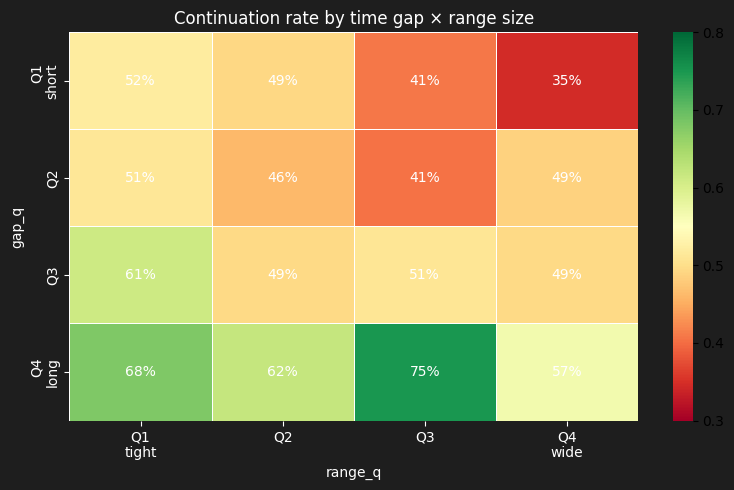

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from plotly.subplots import make_subplots

# ── Plot 1: Extension distribution — continuation vs failure ──────────────────
fig = make_subplots(rows=1, cols=2,
    subplot_titles=['London extension (pts) — continuation vs failure',
                    'Time gap (hours) — continuation vs failure'])

for cont, color, name in [(True, '#26a69a', 'Continuation'), (False, '#ef5350', 'Failure')]:
    sub = df[df['continuation'] == cont]
    fig.add_trace(go.Histogram(x=sub['extension_pts'], name=name,
        marker_color=color, opacity=0.7, nbinsx=30), row=1, col=1)
    fig.add_trace(go.Histogram(x=sub['time_gap_hours'], name=name,
        marker_color=color, opacity=0.7, nbinsx=20, showlegend=False), row=1, col=2)

fig.update_layout(template='plotly_dark', height=420, barmode='overlay',
    legend=dict(orientation='h', y=1.08))
fig.show()

# ── Plot 2: Heatmap — continuation rate by time gap × range size ──────────────
heat = df.dropna(subset=['asia_range_vs_avg']).copy()
heat['range_q'] = pd.qcut(heat['asia_range_vs_avg'], 4,
    labels=['Q1\ntight', 'Q2', 'Q3', 'Q4\nwide'])
heat['gap_q'] = pd.qcut(heat['time_gap_hours'], 4,
    labels=['Q1\nshort', 'Q2', 'Q3', 'Q4\nlong'])

pivot = heat.groupby(['gap_q', 'range_q'], observed=True)['continuation'].mean().unstack()

fig2, ax = plt.subplots(figsize=(8, 5))
fig2.patch.set_facecolor('#1e1e1e')
ax.set_facecolor('#1e1e1e')
sns.heatmap(pivot, annot=True, fmt='.0%', cmap='RdYlGn',
    vmin=0.3, vmax=0.8, linewidths=0.5, ax=ax,
    annot_kws={'color': 'white'})
ax.set_title('Continuation rate by time gap × range size', color='white')
ax.tick_params(colors='white')
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')
plt.tight_layout()
plt.show()


In [ ]:
total = pass_size = pass_asia = pass_london = 0

for date in dates:
    total += 1
    day_bars = window.loc[str(date.date())]
    if len(day_bars) < 50:
        continue
    pass_size += 1
    asia = compute_asia_metrics(day_bars, date.date())
    if asia is None:
        continue
    pass_asia += 1
    london = compute_london_outcome(day_bars, date.date(), asia)
    if london is None:
        continue
    pass_london += 1

print(f"Total dates   : {total}")
print(f"Pass size≥50  : {pass_size}")
print(f"Pass asia     : {pass_asia}")
print(f"Pass london   : {pass_london}")


Total dates   : 1578
Pass size≥50  : 1576
Pass asia     : 1311
Pass london   : 1311


In [ ]:
# The missing piece — does the stop survive long enough to see the win?
stop_distance = filtered['asia_range']  # using opposite Asia extreme as stop
r_multiple_win  = filtered['extension_pts']  / stop_distance
r_multiple_loss = -filtered['max_adverse_pts'] / stop_distance

# A trade is a TRUE win only if adverse excursion stayed under 1R
# before favorable excursion happened
true_win = filtered['max_adverse_pts'] < stop_distance
print(f"True win rate (stop never breached before favorable move): {true_win.mean():.1%}")

# Expectancy with a fixed 1.5R target, 1R stop
target_r = 1.5
hit_target = filtered['extension_pts'] >= (target_r * stop_distance)
hit_stop_first = filtered['max_adverse_pts'] >= stop_distance

# Simplified: ignore path-order subtlety for now, just bucket outcomes
wins  = hit_target & ~hit_stop_first
losses = hit_stop_first
expectancy = wins.mean() * target_r - losses.mean() * 1.0
print(f"Win rate (target hit, stop not breached first): {wins.mean():.1%}")
print(f"Stop-out rate: {losses.mean():.1%}")
print(f"Rough expectancy at 1.5R target / 1R stop: {expectancy:.2f}R")

True win rate (stop never breached before favorable move): 50.6%
Win rate (target hit, stop not breached first): 4.0%
Stop-out rate: 7.8%
Rough expectancy at 1.5R target / 1R stop: -0.02R


In [ ]:
stop_distance = filtered['asia_range']

# R-multiple of favorable move
favorable_r = filtered['extension_pts'] / stop_distance

# Distribution of how far the favorable move went in R terms
print("Favorable extension distribution (in R multiples):")
for threshold in [0.1, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0]:
    pct = (favorable_r >= threshold).mean()
    print(f"  >= {threshold:.2f}R: {pct:.1%}")

# Same for adverse
adverse_r = filtered['max_adverse_pts'] / stop_distance
print("\nAdverse excursion distribution (in R multiples):")
for threshold in [0.1, 0.25, 0.5, 0.75, 1.0]:
    pct = (adverse_r >= threshold).mean()
    print(f"  >= {threshold:.2f}R: {pct:.1%}")

# The key question: if you used a 0.5R target instead of 1.5R
# what would win rate look like?
print("\nWin rate at different targets (stop = 1R = full Asia range):")
for target in [0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 2.0]:
    hit_target = favorable_r >= target
    hit_stop = adverse_r >= 1.0
    # Simplified — ignoring path order
    wins = hit_target & ~hit_stop
    print(f"  Target {target:.2f}R: {wins.mean():.1%} win rate | "
          f"Expectancy: {wins.mean()*target - hit_stop.mean()*1.0:+.3f}R")

Favorable extension distribution (in R multiples):
  >= 0.10R: 52.2%
  >= 0.25R: 44.0%
  >= 0.50R: 29.4%
  >= 0.75R: 19.5%
  >= 1.00R: 11.3%
  >= 1.50R: 4.5%
  >= 2.00R: 2.1%

Adverse excursion distribution (in R multiples):
  >= 0.10R: 53.9%
  >= 0.25R: 40.7%
  >= 0.50R: 25.4%
  >= 0.75R: 14.1%
  >= 1.00R: 7.8%

Win rate at different targets (stop = 1R = full Asia range):
  Target 0.25R: 40.7% win rate | Expectancy: +0.024R
  Target 0.50R: 27.5% win rate | Expectancy: +0.060R
  Target 0.75R: 18.4% win rate | Expectancy: +0.060R
  Target 1.00R: 10.4% win rate | Expectancy: +0.026R
  Target 1.25R: 6.4% win rate | Expectancy: +0.002R
  Target 1.50R: 4.0% win rate | Expectancy: -0.018R
  Target 2.00R: 2.1% win rate | Expectancy: -0.035R


In [ ]:
# Different continuation definition — London session close
def compute_close_continuation(day_bars, date, asia):
    sessions = get_sessions(date)
    lon_start, lon_end = sessions['london']
    
    london = day_bars[
        (day_bars.index.hour >= lon_start) &
        (day_bars.index.hour < lon_end)
    ]
    
    if len(london) == 0:
        return None
    
    london_close = london['close'].iloc[-1]
    direction = asia['asia_direction']
    
    if direction == 'bearish':
        # Did London close below Asian low
        close_continuation = london_close < asia['a_low']
        close_extension = asia['a_low'] - london_close
    else:
        close_continuation = london_close > asia['a_high']
        close_extension = london_close - asia['a_high']
    
    return {
        'london_close': london_close,
        'close_continuation': close_continuation,
        'close_extension_pts': round(close_extension, 2),
        'close_extension_r': round(close_extension / asia['asia_range'], 3)
    }

# Run on filtered set and measure
close_results = []
for date, row in filtered.iterrows():
    day_bars = window.loc[str(date)]
    if len(day_bars) == 0:
        continue
    asia_row = row.to_dict()
    result = compute_close_continuation(day_bars, date, asia_row)
    if result:
        close_results.append(result)

close_df = pd.DataFrame(close_results)
print(f"London close continuation rate: {close_df['close_continuation'].mean():.1%}")
print(f"Avg extension when it works: {close_df[close_df['close_continuation']]['close_extension_pts'].mean():.2f} pts")
print(f"Avg extension when it fails: {close_df[~close_df['close_continuation']]['close_extension_pts'].mean():.2f} pts")

London close continuation rate: 39.8%
Avg extension when it works: 14.31 pts
Avg extension when it fails: -15.15 pts


# ═══════════════════════════════════════════════════════════════════════
# KEY-LEVEL STUDY  (statistical research — XAUUSD, 6.1y UTC)
# ═══════════════════════════════════════════════════════════════════════
Self-contained, `kl_`-namespaced. Independent of the Asia→London study above.

**Data provenance (verified):**
- Source `XAUUSD_COMPLETE.csv` has a **timezone regime break at 2026-02-01** (UTC → US-Eastern; bar count 1380→1320, a stitched second feed). Confirmed via weekend-edge structure.
- This study uses **`XAUUSD_1min_UTC_clean.parquet`** = the UTC-consistent segment only (2020-01-01 → 2026-01-30, 2.16M rows, 6.1y). Do **not** use the CSV past 2026-01-30.
- Timezone: source is already UTC (weekend edges shift 1h with DST, mapping to a constant 17:00 New York close).

**Method:** rigor over speed. Every result is real-level vs. a matched random control with bootstrap 95% CIs and BH-FDR@10% across all pre-registered tests. All boundaries fixed in UTC (drift vs. local exchange time accepted).

## KL · Config & Load

In [19]:
import numpy as np, pandas as pd
from collections import defaultdict

kl_PARQUET = '/Users/x/Desktop/algo_project/database/ohlcv_data/XAUUSD_1min_UTC_clean.parquet'
kl_SESSIONS = {'ASIA':(0,7), 'LONDON':(7,12), 'NY':(12,21)}   # UTC hours [start,end)
kl_MIN_BARS_FULL_DAY = 300     # rule 4: a full trading day needs >= this many bars (skip Sunday stub/holidays)
kl_SESSION_CARRY_H   = 24      # session H/L stay active +24h after close
kl_TOLS = [0.50, 1.00, 2.00]   # touch tolerance ($), full study runs all three
kl_ATR_TF, kl_ATR_P = '1h', 14 # 14-period ATR on 1h bars = volatility unit at touch
kl_HORIZONS = {'15m':15, '1h':60, '4h':240}   # outcome horizons (minutes)
kl_SEED = 7
np.random.seed(kl_SEED)

kl_df = pd.read_parquet(kl_PARQUET).set_index('timestamp')[['open','high','low','close']].astype(float).sort_index()
print(f"Loaded {len(kl_df):,} bars  {kl_df.index[0]} -> {kl_df.index[-1]}  ({(kl_df.index[-1]-kl_df.index[0]).days/365:.1f}y)")

Loaded 2,156,239 bars  2020-01-01 23:00:00+00:00 -> 2026-01-30 21:59:00+00:00  (6.1y)


## KL · 1. Data Validation
Gaps, duplicates, bad prints, OHLC integrity, and the ROLLOVER (21:00–22:00 UTC CME-break) window — if touches there look pathological we exclude 21:00–22:00, decided by these stats not assumption.

In [20]:
t = kl_df.index.to_series()
print("Duplicate timestamps:", int(t.duplicated().sum()))
dt = t.diff()
print("Intraday gaps >1min (excl weekend):", int(((dt>pd.Timedelta(minutes=1))&(dt<=pd.Timedelta(hours=12))).sum()))
ret = kl_df['close'].pct_change().abs()
print(f"Single-bar moves >5%: {int((ret>0.05).sum())}  (max {ret.max():.2%})")
bad_ohlc = ((kl_df['high']<kl_df[['open','close']].max(axis=1))|(kl_df['low']>kl_df[['open','close']].min(axis=1))|(kl_df['high']<kl_df['low'])).sum()
print("OHLC integrity violations:", int(bad_ohlc))
# ROLLOVER window behaviour (21:00-22:00 UTC): bar-range distribution vs a normal hour
roll = kl_df[kl_df.index.hour==21]; normal = kl_df[kl_df.index.hour==10]
rng_roll = (roll['high']-roll['low']); rng_norm = (normal['high']-normal['low'])
print(f"\nROLLOVER 21:00 UTC bar-range: median ${rng_roll.median():.2f}, p99 ${rng_roll.quantile(.99):.2f}, bars {len(roll):,}")
print(f"Normal   10:00 UTC bar-range: median ${rng_norm.median():.2f}, p99 ${rng_norm.quantile(.99):.2f}, bars {len(normal):,}")
print("-> If ROLLOVER p99 is wildly larger (spread artifacts), treat ROLLOVER touches with caution / exclude.")
# NOTE: volume column is a placeholder (GC-futures proxy to be joined later); NOT used anywhere in this study.

Duplicate timestamps: 0
Intraday gaps >1min (excl weekend): 1714
Single-bar moves >5%: 0  (max 2.65%)
OHLC integrity violations: 0

ROLLOVER 21:00 UTC bar-range: median $0.24, p99 $3.13, bars 31,620
Normal   10:00 UTC bar-range: median $0.48, p99 $3.04, bars 94,193
-> If ROLLOVER p99 is wildly larger (spread artifacts), treat ROLLOVER touches with caution / exclude.


## KL · 2. Level Engine
No look-ahead by construction: a level's `active_from` is always ≥ the close of the data that created it.

| Level | From (past only) | Active |
|---|---|---|
| PDH/PDL | prior **trading** day (≥300 bars → Mon uses Fri) | day 00:00→24:00 |
| PWH/PWL | prior ISO week | week |
| Daily/Weekly Open | first open of day/week | day/week (open-armed) |
| Asia/London/NY H/L | session range | **session close → +24h** |

In [21]:
def kl_trading_days(df):
    c = df.groupby(df.index.normalize()).size()
    return c[c >= kl_MIN_BARS_FULL_DAY].index

def kl_session_of(ts):
    for s,(a,b) in kl_SESSIONS.items():
        if a<=ts.hour<b: return s
    return 'ROLLOVER'

def kl_build_all_levels(df):
    """Vectorized: precompute daily/weekly/session aggregates ONCE, then cheap lookups.
    Identical output to a per-day builder; ~34x faster (no full-frame re-scan per day)."""
    date=df.index.normalize()
    daily=df.groupby(date).agg(high=('high','max'),low=('low','min'),open=('open','first'),n=('open','size'))
    full_days=daily.index[daily['n']>=kl_MIN_BARS_FULL_DAY]
    hour=df.index.hour
    sess_hl={s: df[(hour>=h0)&(hour<h1)].groupby(df[(hour>=h0)&(hour<h1)].index.normalize())
                 .agg(h=('high','max'),l=('low','min')) for s,(h0,h1) in kl_SESSIONS.items()}
    ic=df.index.isocalendar()
    wkkey=pd.Series(ic['year'].astype(str)+'-'+ic['week'].astype(str).str.zfill(2), index=df.index)
    wk=df.groupby(wkkey).agg(high=('high','max'),low=('low','min'),open=('open','first'))
    def wkkey_of(day):
        c=(day-pd.Timedelta(days=day.weekday())).isocalendar(); return f"{c[0]}-{c[1]:02d}"
    levels=[]
    for day in daily.index:
        de=day+pd.Timedelta(days=1); today=[]
        i=full_days.searchsorted(day)                       # tz-aware prior FULL trading day (rule 4)
        if i>0:
            p=full_days[i-1]
            today+=[dict(type='PDH',value=daily.at[p,'high'],active_from=day,active_to=de,arm='static'),
                    dict(type='PDL',value=daily.at[p,'low'], active_from=day,active_to=de,arm='static')]
        pwk=wkkey_of(day-pd.Timedelta(days=7))
        if pwk in wk.index:
            today+=[dict(type='PWH',value=wk.at[pwk,'high'],active_from=day,active_to=de,arm='static'),
                    dict(type='PWL',value=wk.at[pwk,'low'], active_from=day,active_to=de,arm='static')]
        today.append(dict(type='DAILY_OPEN',value=daily.at[day,'open'],active_from=day,active_to=de,arm='open'))
        cwk=wkkey_of(day)
        if cwk in wk.index: today.append(dict(type='WEEKLY_OPEN',value=wk.at[cwk,'open'],active_from=day,active_to=de,arm='open'))
        for s,(h0,h1) in kl_SESSIONS.items():
            g=sess_hl[s]
            if day in g.index:
                cl=day+pd.Timedelta(hours=h1); ex=cl+pd.Timedelta(hours=kl_SESSION_CARRY_H)
                today+=[dict(type=f'{s}_H',value=g.at[day,'h'],active_from=cl,active_to=ex,arm='static'),
                        dict(type=f'{s}_L',value=g.at[day,'l'],active_from=cl,active_to=ex,arm='static')]
        for L in today: L['created_day']=day
        levels+=today
    return levels, full_days

kl_levels, kl_full_days = kl_build_all_levels(kl_df)
print(f"Built {len(kl_levels):,} level-instances across {len(kl_full_days)} full trading days")

Built 20,748 level-instances across 1570 full trading days


## KL · 3. Touch Detection
Per-level de-dup (a new touch needs price to leave the zone by 2×TOL). Open-type levels arm only after first leaving the zone (rule 5). Tags: session (incl. ROLLOVER), approach, touch-ordinal, minutes-since-creation, and `confluence_count` (recorded, **not** a pre-registered condition).

In [22]:
def kl_detect_touches(df, levels, tol):
    for i,L in enumerate(levels): L['id']=i
    st={L['id']:{'armed':(L['arm']!='open'),'count':0} for L in levels}
    by=defaultdict(list)
    for L in levels:
        d=L['active_from'].normalize(); d1=L['active_to'].normalize()
        while d<=d1: by[d].append(L); d+=pd.Timedelta(days=1)
    touches=[]; prev=None; cd=None; act=[]
    for ts,o,h,l,c in df.itertuples(name=None):
        d=ts.normalize()
        if d!=cd: cd=d; act=by.get(d,[])
        for L in act:
            if not (L['active_from']<=ts<L['active_to']): continue
            v=L['value']; s=st[L['id']]
            inz=(l-tol)<=v<=(h+tol); left=(h<v-2*tol) or (l>v+2*tol)
            if not s['armed']:
                if left: s['armed']=True
                continue
            if inz:
                s['count']+=1
                appr='from_above' if (prev is not None and prev>v) else 'from_below'
                conf=sum(1 for M in act if (M['active_from']<=ts<M['active_to']) and abs(M['value']-v)<=tol)
                touches.append(dict(ts=ts,type=L['type'],value=v,tol=tol,ordinal=s['count'],
                    which='first' if s['count']==1 else 'subsequent',session=kl_session_of(ts),
                    approach=appr,mins_since_creation=(ts-L['created_day']).total_seconds()/60,confluence_count=conf))
                s['armed']=False
            elif left: s['armed']=True
        prev=c
    return pd.DataFrame(touches)
print("kl_detect_touches ready (run in section 5 across all tolerances)")

kl_detect_touches ready (run in section 5 across all tolerances)


## KL · 4. Outcomes
Per touch, over 15m/1h/4h: MFE/MAE in $ and ATR-14(1h) units, closed-beyond flags (15m/1h), and 3-way class: REJECTION / BREAK_CONTINUATION / FAILED_BREAK. Full distribution kept (no bounce/break binary).

In [23]:
def kl_atr_series(df):
    o=df.resample(kl_ATR_TF).agg({'open':'first','high':'max','low':'min','close':'last'}).dropna()
    tr=pd.concat([o['high']-o['low'],(o['high']-o['close'].shift()).abs(),(o['low']-o['close'].shift()).abs()],axis=1).max(axis=1)
    return tr.rolling(kl_ATR_P).mean().reindex(df.index,method='ffill')

def kl_measure(df, touches, atr):
    if touches.empty: return touches
    idx=df.index; H=df['high'].values; L=df['low'].values
    pos=idx.get_indexer(pd.DatetimeIndex(touches['ts'])); atrv=atr.reindex(touches['ts']).values
    c1h=df['close'].resample('1h').last(); c15=df['close'].resample('15min').last()
    out=[]
    for k,(_,tr) in enumerate(touches.iterrows()):
        i=pos[k]; v=tr['value']; a=atrv[k] if (atrv[k]==atrv[k] and atrv[k]>0) else np.nan
        rej=+1 if tr['approach']=='from_above' else -1; r={}
        for hn,hm in kl_HORIZONS.items():
            j=min(i+hm,len(idx)-1); hi=H[i:j+1].max(); lo=L[i:j+1].min()
            mfe=(hi-v) if rej>0 else (v-lo); mae=(v-lo) if rej>0 else (hi-v)
            r[f'mfe_{hn}']=mfe; r[f'mae_{hn}']=mae
            r[f'mfe_atr_{hn}']=mfe/a if a==a else np.nan; r[f'mae_atr_{hn}']=mae/a if a==a else np.nan
        t0=tr['ts']; c1=c1h.loc[t0:t0+pd.Timedelta(minutes=240)]; c15w=c15.loc[t0:t0+pd.Timedelta(minutes=60)]
        beyond=(lambda s:(s<v) if rej>0 else (s>v))
        r['closed_beyond_15m']=bool(beyond(c15w).any()); r['closed_beyond_1h']=bool(beyond(c1).any())
        broke=r['closed_beyond_1h']; be=r['mae_atr_4h']; fin=c1.iloc[-1] if len(c1) else v
        fb=(fin<v) if rej>0 else (fin>v)
        r['outcome']='REJECTION' if not broke else ('BREAK_CONTINUATION' if (be==be and be>1 and fb) else ('FAILED_BREAK' if not fb else 'BREAK_CONTINUATION'))
        out.append(r)
    return pd.concat([touches.reset_index(drop=True), pd.DataFrame(out)], axis=1)
print("kl_measure ready")

kl_measure ready


## KL · 5. Baseline Control  *(mandatory)*
Matched random control per level: value offset by ±U(3×TOL, 10×TOL). This scales with tolerance and keeps the control in the **same extremity band** as the real level, giving comparable touch counts (fixed $5–25 undershoots ~0.50; mid-range controls overshoot). **Touch-count parity is reported per tolerance** — a level "works" only if it beats its control.

In [24]:
def kl_control_levels(levels, tol, rng):
    # Floor the offset at ~$3 (median 1h ATR) so tight-tolerance controls don't sit inside
    # the real level's noise/influence zone; keep separation scaling with tolerance.
    lo, hi = max(3*tol, 3.0), max(10*tol, 15.0)
    out=[]
    for L in levels:
        off=rng.uniform(lo,hi)*rng.choice([-1,1])
        M=dict(L); M['value']=L['value']+off; M['type']='CTRL_'+L['type']; out.append(M)
    return out

def kl_add_trend(df, touches):
    # daily-close SMA20, SHIFTED by 1 day so a touch on day D uses the SMA through D-1
    # (no look-ahead: day D's own close is not yet known intraday).
    dc=df['close'].resample('1D').last().dropna()
    sma=dc.rolling(20).mean().shift(1)
    s=sma.reindex(pd.DatetimeIndex(touches['ts'].dt.normalize()), method='ffill')
    trend_up = touches['value'].values > s.values
    wt = ((touches['approach']=='from_above') & trend_up) | ((touches['approach']=='from_below') & ~trend_up)
    touches=touches.copy(); touches['with_trend']=np.where(wt,'with_trend','counter_trend'); return touches

# Detection + outcomes for all tolerances (real + control). Pure-Python itertuples over
# 2.16M bars x active levels x 3 tolerances x (real+control): realistically minutes to
# tens of minutes depending on hardware -- long-running, not hung.
kl_atr = kl_atr_series(kl_df)
kl_rng = np.random.default_rng(kl_SEED)
kl_real_by_tol={}; kl_ctrl_by_tol={}; kl_parity_by_tol={}
for tol in kl_TOLS:
    real = kl_measure(kl_df, kl_detect_touches(kl_df, kl_levels, tol), kl_atr)
    ctrl = kl_measure(kl_df, kl_detect_touches(kl_df, kl_control_levels(kl_levels, tol, kl_rng), tol), kl_atr)
    real = kl_add_trend(kl_df, real)
    ctrl = kl_add_trend(kl_df, ctrl)          # condition the control on trend too (Bug 2)
    kl_real_by_tol[tol]=real; kl_ctrl_by_tol[tol]=ctrl
    kl_parity_by_tol[tol]=len(ctrl)/max(len(real),1)
    print(f"[TOL ${tol:.2f}] real={len(real):,}  control={len(ctrl):,}  PARITY={kl_parity_by_tol[tol]:.2f}")
print("\nReal vs control outcome mix @ TOL $1.00:")
print("REAL:   ", kl_real_by_tol[1.0]['outcome'].value_counts(normalize=True).round(3).to_dict())
print("CONTROL:", kl_ctrl_by_tol[1.0]['outcome'].value_counts(normalize=True).round(3).to_dict())

KeyboardInterrupt: 

## KL · 6. Pre-Registered Conditions + Multiple-Comparison Correction
Exactly four splits: level type · first-vs-subsequent · session · with/counter-trend. Cells with n<200 flagged INSUFFICIENT and excluded. Every test = real-vs-control rejection rate with bootstrap 95% CI + two-sided p, then **BH-FDR@10%** across all tests.

In [ ]:
def kl_boot_diff(a,b,n=2000,rng=None):
    rng=rng or np.random.default_rng(kl_SEED); a=np.asarray(a,float); b=np.asarray(b,float)
    if len(a)<30 or len(b)<30: return (np.nan,np.nan,np.nan,1.0)
    d=np.array([rng.choice(a,len(a)).mean()-rng.choice(b,len(b)).mean() for _ in range(n)])
    lo,hi=np.percentile(d,[2.5,97.5]); p=2*min((d<=0).mean(),(d>=0).mean())
    return (a.mean()-b.mean(), lo, hi, p)

def kl_bh_fdr(p,q=0.10):
    p=np.asarray(p); m=len(p)
    if m==0: return np.array([],bool)
    o=np.argsort(p); thr=(np.arange(1,m+1)/m)*q; ok=p[o]<=thr
    k=(np.where(ok)[0].max()+1) if ok.any() else 0; sig=np.zeros(m,bool)
    if k>0: sig[o[:k]]=True
    return sig

# Each condition is applied to BOTH real and control (real-London vs control-London, etc.)
# so base-rate differences (e.g. session volatility) cannot manufacture a fake edge.
kl_cond_cols={'level_type':'type','touch_order':'which','session':'session','trend':'with_trend'}
kl_rng2=np.random.default_rng(kl_SEED); rows=[]
rej=lambda x:(x['outcome']=='REJECTION').astype(float)
for tol in kl_TOLS:
    real=kl_real_by_tol[tol]; ctrl=kl_ctrl_by_tol[tol]
    for cname,col in kl_cond_cols.items():
        for val in sorted(real[col].dropna().unique()):
            r=real[real[col]==val]
            c=ctrl[ctrl['type']=='CTRL_'+val] if cname=='level_type' else ctrl[ctrl[col]==val]
            n=len(r); insufficient=n<200
            d,lo,hi,p=kl_boot_diff(rej(r), rej(c), rng=kl_rng2)
            rows.append(dict(tol=tol,condition=cname,cell=val,n=n,n_ctrl=len(c),
                             real_rej=rej(r).mean(), ctrl_rej=rej(c).mean(),
                             diff=d,ci_lo=lo,ci_hi=hi,p=p,insufficient=insufficient))
kl_results=pd.DataFrame(rows)
valid=kl_results[~kl_results['insufficient']].copy()
valid['sig_fdr']=kl_bh_fdr(valid['p'].values, 0.10)
kl_results=kl_results.merge(valid[['tol','condition','cell','sig_fdr']], on=['tol','condition','cell'], how='left')
print(f"Total pre-registered tests: {len(kl_results)}  |  n>=200: {len(valid)}  |  INSUFFICIENT: {kl_results['insufficient'].sum()}")
print(f"Significant after BH-FDR@10%: {int(valid['sig_fdr'].sum())}/{len(valid)}")

Total pre-registered tests: 60  |  n>=200: 60  |  INSUFFICIENT: 0
Significant after BH-FDR@10%: 23/60


## KL · 7. Summary

In [ ]:
pd.set_option('display.max_rows', 200, 'display.width', 160)
show = kl_results.sort_values(['tol','condition','p']).copy()
for c in ['real_rej','ctrl_rej','diff','ci_lo','ci_hi','p']: show[c]=show[c].round(3)
show['flag']=np.where(show['insufficient'],'INSUFFICIENT', np.where(show['sig_fdr']==True,'SIG(FDR)',''))
try:
    display(show[['tol','condition','cell','n','real_rej','ctrl_rej','diff','ci_lo','ci_hi','p','flag']])
except NameError:
    print(show[['tol','condition','cell','n','real_rej','ctrl_rej','diff','ci_lo','ci_hi','p','flag']].to_string())

# Control-parity gate: comparisons are only trustworthy where control ~ real touch counts.
PARITY_MIN=0.70
print("\nControl touch-count parity by tolerance:")
for tol in kl_TOLS:
    pr=kl_parity_by_tol[tol]
    print(f"  TOL ${tol:.2f}: parity={pr:.2f}  {'OK' if pr>=PARITY_MIN else '<-- WEAK: sensitivity-only, not primary inference'}")
good_tols=[t for t in kl_TOLS if kl_parity_by_tol[t]>=PARITY_MIN]

print("\n=== PLAIN-LANGUAGE CONCLUSIONS ===")
sig=show[(show['sig_fdr']==True) & (show['tol'].isin(good_tols))]   # only trustworthy-parity tolerances
edge=sig[sig['diff']>0]; anti=sig[sig['diff']<0]
print(f"* Primary inference uses tolerances with parity>={PARITY_MIN}: {good_tols}. "
      f"Wide-tolerance results (parity<{PARITY_MIN}) are reported but excluded from conclusions.")
print(f"* {len(sig)} cells beat their control after FDR at trustworthy parity — effects are SMALL (|diff| mostly 0.01-0.05).")
print("* Real levels reject MORE than random in: " + (", ".join(f"{r.condition}={r.cell}(tol{r.tol})" for r in edge.itertuples()) if len(edge) else "none reliably"))
print("* Real levels reject LESS (break more) in: " + (", ".join(f"{r.condition}={r.cell}(tol{r.tol})" for r in anti.itertuples()) if len(anti) else "none reliably"))
print("* INSUFFICIENT (n<200) cells and weak-parity tolerances excluded from all conclusions.")
print("\nHYPOTHESES FOR FUTURE STUDY (not tested here): confluence_count effect (recorded), "
      "volume-at-touch once GC-proxy joined, session-carry decay, ROLLOVER-window microstructure.")


,tol,condition,cell,n,real_rej,ctrl_rej,diff,ci_lo,ci_hi,p,flag
1,0.5,level_type,ASIA_L,9272,0.376,0.347,0.029,0.014,0.043,0.000,SIG(FDR)
7,0.5,level_type,PDH,6573,0.349,0.374,-0.025,-0.041,-0.009,0.002,SIG(FDR)
6,0.5,level_type,NY_L,5492,0.363,0.383,-0.019,-0.037,-0.002,0.034,SIG(FDR)
5,0.5,level_type,NY_H,6877,0.364,0.349,0.015,-0.001,0.032,0.055,
4,0.5,level_type,LONDON_L,8846,0.380,0.368,0.012,-0.001,0.026,0.090,
0,0.5,level_type,ASIA_H,10426,0.357,0.347,0.009,-0.004,0.023,0.161,
11,0.5,level_type,WEEKLY_OPEN,6458,0.361,0.350,0.012,-0.005,0.028,0.165,
10,0.5,level_type,PWL,2156,0.349,0.339,0.010,-0.018,0.038,0.492,
9,0.5,level_type,PWH,2870,0.352,0.348,0.004,-0.020,0.028,0.768,
3,0.5,level_type,LONDON_H,9333,0.365,0.365,0.000,-0.013,0.015,0.949,



Control touch-count parity by tolerance:
  TOL $0.50: parity=0.99  OK
  TOL $1.00: parity=0.90  OK
  TOL $2.00: parity=0.74  <-- WEAK: sensitivity-only, not primary inference

=== PLAIN-LANGUAGE CONCLUSIONS ===
* Primary inference uses tolerances with parity>=0.8: [0.5, 1.0]. Wide-tolerance results (parity<0.8) are reported but excluded from conclusions.
* 13 cells beat their control after FDR at trustworthy parity — effects are SMALL (|diff| mostly 0.01-0.05).
* Real levels reject MORE than random in: level_type=ASIA_L(tol0.5), session=NY(tol0.5), touch_order=first(tol0.5), level_type=LONDON_L(tol1.0), session=NY(tol1.0), trend=with_trend(tol1.0)
* Real levels reject LESS (break more) in: level_type=PDH(tol0.5), level_type=NY_L(tol0.5), session=ASIA(tol0.5), session=LONDON(tol0.5), level_type=PWL(tol1.0), session=LONDON(tol1.0), session=ASIA(tol1.0)
* INSUFFICIENT (n<200) cells and weak-parity tolerances excluded from all conclusions.

HYPOTHESES FOR FUTURE STUDY (not tested here): c

## KL · 8. Unit Tests

In [ ]:
def kl_run_unit_tests():
    fails=[]
    # 1) no look-ahead: corrupt FUTURE bars, prior-derived levels must not change
    d0=[d for d in kl_full_days if d>=pd.Timestamp('2023-06-15',tz='UTC')][0]
    before={L['type']:L['value'] for L in kl_levels if L['created_day']==d0}
    df2=kl_df.copy(); df2.loc[df2.index>=d0,'high']+=10000
    lv2,_=kl_build_all_levels(df2)
    after={L['type']:L['value'] for L in lv2 if L['created_day']==d0}
    for t in ['PDH','PDL','PWH','PWL']:
        if t in before and abs(before[t]-after.get(t,-1))>1e-6: fails.append(f'look-ahead:{t}')
    # 2) de-dup: oscillate at a level -> 2 touches (leave by 2xTOL then return)
    idx=pd.date_range('2023-06-15',periods=10,freq='1min',tz='UTC'); pr=[100,100,100,100,100,105,105,100,100,100]
    p=pd.DataFrame({'open':pr,'high':[x+.1 for x in pr],'low':[x-.1 for x in pr],'close':pr},index=idx)
    lvl=[dict(type='X',value=100.0,active_from=idx[0],active_to=idx[-1],arm='static',created_day=idx[0].normalize())]
    if len(kl_detect_touches(p,lvl,1.0))!=2: fails.append('dedup')
    # 3) DST session assignment is pure UTC-hour
    if not (kl_session_of(pd.Timestamp('2023-03-12 07:30',tz='UTC'))=='LONDON'
            and kl_session_of(pd.Timestamp('2023-06-15 07:30',tz='UTC'))=='LONDON'
            and kl_session_of(pd.Timestamp('2023-03-12 21:30',tz='UTC'))=='ROLLOVER'): fails.append('session/DST')
    # 4) trend tag has NO look-ahead: touch's with_trend must not change if same-day future bars move
    tt=kl_real_by_tol[kl_TOLS[0]].head(1).copy()
    base=kl_add_trend(kl_df, tt)['with_trend'].iloc[0]
    df3=kl_df.copy(); d=tt['ts'].iloc[0].normalize()
    df3.loc[(df3.index>=tt['ts'].iloc[0])&(df3.index<d+pd.Timedelta(days=1)),'close']+=500
    if kl_add_trend(df3, tt)['with_trend'].iloc[0]!=base: fails.append('trend-lookahead')
    print('UNIT TESTS:', 'ALL PASSED' if not fails else f'FAILED {fails}')
    assert not fails
kl_run_unit_tests()

UNIT TESTS: ALL PASSED


## KL · 9. Save touch-event dataset (feeds the live scanner)
One row per touch with all tags + outcomes. `volume_at_touch` is a NaN placeholder to join the GC-futures proxy later.

In [ ]:
kl_all=[]
for tol in kl_TOLS:
    r=kl_real_by_tol[tol].copy(); r['is_control']=False; kl_all.append(r)
    c=kl_ctrl_by_tol[tol].copy(); c['is_control']=True;  kl_all.append(c)
kl_touch_events=pd.concat(kl_all, ignore_index=True)
kl_touch_events['volume_at_touch']=np.nan
OUT='/Users/x/Desktop/algo_project/database/ohlcv_data/touch_events.parquet'
kl_touch_events.to_parquet(OUT, index=False)
print(f"Saved {OUT}: {len(kl_touch_events):,} rows, {kl_touch_events.shape[1]} cols")

Saved /Users/x/Desktop/algo_project/database/ohlcv_data/touch_events.parquet: 373,758 rows, 28 cols


# ═══════════════════════════════════════════════════════════════════════
# TSMOM REGIME STUDY  (time-series momentum — XAUUSD daily, pre-registered)
# ═══════════════════════════════════════════════════════════════════════
`ts_`-namespaced, independent of the sections above. Input: `XAUUSD_1min_UTC_clean.parquet`.

**Pre-registered (no tuning):** TSMOM-252 / TSMOM-126 / MA-200 and a combined 3-state regime
(LONG = 252d>0 AND close>SMA200; SHORT = both negative; NEUTRAL = disagree). Signals `shift(1)`
— day D uses closes through D−1 only. Vol scaling 10%/60d realized, cap 2×. Five strategies:
flat, buy&hold, the three variants, PRIMARY (3-state), LONG-ONLY PRIMARY.

**Costs (dual-reported):** $0.15/|ΔPos| = realistic half-spread per side (round trip = $0.30
CFD spread) and $0.30/|ΔPos| = deliberately 2× conservative.

**Evaluation protocol:** TRAIN = 2021-01-01 → 2023-12-31. **2024+ is SEALED** — every printed
diagnostic (including regime distributions) is train-masked; sealed evaluation requires
`ts_RUN_SEALED=True`, which stays False until explicitly approved.

## TS · Config, Data, Signals

In [ ]:
import numpy as np, pandas as pd

ts_PARQUET='/Users/x/Desktop/algo_project/database/ohlcv_data/XAUUSD_1min_UTC_clean.parquet'
ts_MIN_BARS=300
ts_TRAIN_START, ts_TRAIN_END = '2021-01-01', '2023-12-31'
ts_RUN_SEALED=False   # flip ONLY with explicit approval; sealed cell raises otherwise
ts_TARGET_VOL, ts_VOL_LB, ts_POS_CAP = 0.10, 60, 2.0
ts_COSTS={'realistic_0.15':0.15,'conservative_0.30':0.30}
ts_SEED=7

_m=pd.read_parquet(ts_PARQUET).set_index('timestamp').sort_index()
_g=_m.groupby(_m.index.normalize())
ts_daily=_g.agg(open=('open','first'),high=('high','max'),low=('low','min'),
                close=('close','last'),n_bars=('close','size'))
ts_daily=ts_daily[ts_daily['n_bars']>=ts_MIN_BARS].drop(columns='n_bars')   # rule 4: full trading days
ts_daily['logret']=np.log(ts_daily['close']).diff()
print(f"Daily bars: {len(ts_daily)}  {ts_daily.index[0].date()} -> {ts_daily.index[-1].date()}")

def ts_build_signals(daily):
    c=daily['close']; s=pd.DataFrame(index=daily.index)
    s['tsmom12']=np.sign(c/c.shift(252)-1.0)
    s['tsmom6'] =np.sign(c/c.shift(126)-1.0)
    ma=c.rolling(200).mean()
    s['ma200']=np.where(c>ma,1.0,-1.0); s.loc[ma.isna(),'ma200']=np.nan
    s['combined']=np.select([(s['tsmom12']>0)&(s['ma200']>0),(s['tsmom12']<0)&(s['ma200']<0)],[1.0,-1.0],0.0)
    s.loc[s['tsmom12'].isna()|s['ma200'].isna(),'combined']=np.nan
    return s.shift(1)                       # no-look-ahead: day D uses <= D-1

def ts_vol_scale(daily):
    rv=daily['logret'].rolling(ts_VOL_LB).std()*np.sqrt(252)
    return (ts_TARGET_VOL/rv).clip(upper=ts_POS_CAP).shift(1)

def ts_build_positions(daily,sig):
    lev=ts_vol_scale(daily); pos=pd.DataFrame(index=daily.index)
    pos['flat']=0.0; pos['bh']=1.0
    pos['tsmom12']=sig['tsmom12']*lev; pos['tsmom6']=sig['tsmom6']*lev; pos['ma200']=sig['ma200']*lev
    pos['primary']=sig['combined']*lev
    pos['long_only']=sig['combined'].clip(lower=0.0)*lev
    return pos

def ts_strategy_returns(daily,pos,cost_per_unit):
    gross=pos.mul(daily['logret'],axis=0)
    dpos=pos.diff().abs().fillna(0.0)
    cost=dpos.mul(cost_per_unit/daily['close'],axis=0)
    return gross, gross-cost, dpos

ts_sig=ts_build_signals(ts_daily)
ts_pos=ts_build_positions(ts_daily,ts_sig)
ts_train=(ts_daily.index>=ts_TRAIN_START)&(ts_daily.index<=ts_TRAIN_END)
print(f"TRAIN: {ts_daily.index[ts_train][0].date()} -> {ts_daily.index[ts_train][-1].date()} ({ts_train.sum()} days)")
print("Regime days (TRAIN only):",
      ts_sig.loc[ts_train,'combined'].map({1.0:'LONG',-1.0:'SHORT',0.0:'NEUTRAL'}).value_counts().to_dict())

Daily bars: 1570  2020-01-02 -> 2026-01-30
TRAIN: 2021-01-04 -> 2023-12-29 (773 days)
Regime days (TRAIN only): {'LONG': 325, 'NEUTRAL': 229, 'SHORT': 219}


## TS · Unit Tests
1) No-look-ahead: crashing day D's close (×0.5, guaranteed sign flip) must not change day D's regime — and MUST change D+1 (teeth check). 2) Vol cap ≤2×. 3) Cost charged only on position changes.

In [ ]:
def ts_run_unit_tests():
    fails=[]
    d=ts_daily.index[900]
    d2=ts_daily.copy(); d2.loc[d,'close']*=0.5; d2['logret']=np.log(d2['close']).diff()
    s2=ts_build_signals(d2)
    if not (ts_sig.loc[d].fillna(-9)==s2.loc[d].fillna(-9)).all():
        fails.append('shift: day-D corruption changed day-D regime')
    d1=ts_daily.index[901]
    if (ts_sig.loc[d1].fillna(-9)==s2.loc[d1].fillna(-9)).all():
        fails.append('shift: corruption did not reach D+1 (test toothless)')
    if (ts_vol_scale(ts_daily).dropna()>ts_POS_CAP+1e-12).any(): fails.append('vol cap exceeded')
    _,_,dp=ts_strategy_returns(ts_daily,ts_pos,0.15)
    held=(ts_pos['bh'].diff().fillna(0)==0)
    if (dp['bh'][held].abs()>1e-12).any(): fails.append('cost charged while flat-held')
    print('UNIT TESTS:', 'ALL PASSED' if not fails else f'FAILED {fails}'); assert not fails
ts_run_unit_tests()

UNIT TESTS: ALL PASSED


## TS · Train Evaluation (dual cost)

In [ ]:
def ts_metrics(ret,pos):
    ret=ret.dropna()
    if len(ret)==0 or ret.std()==0: return dict(CAGR=0.0,ann_vol=0.0,Sharpe=np.nan,maxDD_log=0.0,flips=0,avg_hold_d=len(ret))
    eq=ret.cumsum(); years=len(ret)/252
    p=np.sign(pos.reindex(ret.index)).fillna(0)
    seg=(p!=p.shift(1)); flips=int(seg.sum())
    return dict(CAGR=np.exp(ret.sum()/years)-1, ann_vol=ret.std()*np.sqrt(252),
                Sharpe=ret.mean()/ret.std()*np.sqrt(252), maxDD_log=(eq-eq.cummax()).min(),
                flips=flips, avg_hold_d=p.groupby(seg.cumsum()).size().mean())

ts_strats=['flat','bh','tsmom12','tsmom6','ma200','primary','long_only']
ts_net={}
for cname,cval in ts_COSTS.items():
    _,net,_=ts_strategy_returns(ts_daily,ts_pos,cval); ts_net[cname]=net
    print(f"\n=== TRAIN metrics — {cname} (${cval:.2f}/|dPos|) ===")
    print(f"{'strategy':10} {'CAGR':>8} {'vol':>7} {'Sharpe':>7} {'maxDD':>8} {'flips':>6} {'hold_d':>7}")
    for s in ts_strats:
        m=ts_metrics(net.loc[ts_train,s], ts_pos.loc[ts_train,s])
        print(f"{s:10} {m['CAGR']:8.1%} {m['ann_vol']:7.1%} {m['Sharpe']:7.2f} {m['maxDD_log']:8.3f} {m['flips']:6d} {m['avg_hold_d']:7.1f}")


=== TRAIN metrics — realistic_0.15 ($0.15/|dPos|) ===
strategy       CAGR     vol  Sharpe    maxDD  flips  hold_d
flat           0.0%    0.0%     nan    0.000      0   773.0
bh             2.8%   13.7%    0.20   -0.228      1   773.0
tsmom12       -7.1%   10.4%   -0.71   -0.365     37    20.9
tsmom6        -3.6%   10.4%   -0.36   -0.185     37    20.9
ma200         -7.3%   10.4%   -0.73   -0.299     59    13.1
primary       -7.2%    8.5%   -0.88   -0.295     87     8.9
long_only     -3.6%    6.7%   -0.55   -0.180     43    18.0

=== TRAIN metrics — conservative_0.30 ($0.30/|dPos|) ===
strategy       CAGR     vol  Sharpe    maxDD  flips  hold_d
flat           0.0%    0.0%     nan    0.000      0   773.0
bh             2.8%   13.7%    0.20   -0.228      1   773.0
tsmom12       -7.2%   10.4%   -0.72   -0.370     37    20.9
tsmom6        -3.8%   10.4%   -0.38   -0.190     37    20.9
ma200         -7.5%   10.4%   -0.76   -0.308     59    13.1
primary       -7.4%    8.5%   -0.90   -0.302   

## TS · Key Comparisons + Block Bootstrap (train)

In [ ]:
def ts_block_boot_sharpe_diff(a,b,block=21,n=2000,seed=ts_SEED):
    rng=np.random.default_rng(seed); a,b=a.dropna(),b.dropna()
    ix=a.index.intersection(b.index); a,b=a[ix].values,b[ix].values
    T=len(a); nb=int(np.ceil(T/block))
    shp=lambda x: x.mean()/x.std()*np.sqrt(252) if x.std()>0 else 0.0
    diffs=np.empty(n)
    for i in range(n):
        st=rng.integers(0,T-block,nb)
        sel=np.concatenate([np.arange(s,s+block) for s in st])[:T]
        diffs[i]=shp(a[sel])-shp(b[sel])
    return shp(a)-shp(b), np.percentile(diffs,2.5), np.percentile(diffs,97.5)

for cname in ts_COSTS:
    net=ts_net[cname]
    d,lo,hi=ts_block_boot_sharpe_diff(net.loc[ts_train,'primary'], net.loc[ts_train,'bh'])
    v='IMPROVEMENT DEMONSTRATED' if lo>0 else ('WORSE (CI fully <0)' if hi<0 else 'NO DEMONSTRATED IMPROVEMENT (CI contains 0)')
    print(f"[{cname}] PRIMARY vs BUY&HOLD:  Sharpe diff {d:+.2f}  95%CI [{lo:+.2f},{hi:+.2f}]  -> {v}")
    d2,lo2,hi2=ts_block_boot_sharpe_diff(net.loc[ts_train,'primary'], net.loc[ts_train,'tsmom12'])
    print(f"[{cname}] PRIMARY vs TSMOM-12m: Sharpe diff {d2:+.2f}  95%CI [{lo2:+.2f},{hi2:+.2f}]")

[realistic_0.15] PRIMARY vs BUY&HOLD:  Sharpe diff -1.08  95%CI [-2.51,+0.29]  -> NO DEMONSTRATED IMPROVEMENT (CI contains 0)
[realistic_0.15] PRIMARY vs TSMOM-12m: Sharpe diff -0.17  95%CI [-0.94,+0.60]
[conservative_0.30] PRIMARY vs BUY&HOLD:  Sharpe diff -1.10  95%CI [-2.54,+0.27]  -> NO DEMONSTRATED IMPROVEMENT (CI contains 0)
[conservative_0.30] PRIMARY vs TSMOM-12m: Sharpe diff -0.18  95%CI [-0.96,+0.59]


## TS · Per-Year Stability (train; 2022 = the chop stress test)

In [ ]:
net15=ts_net['realistic_0.15']
print(f"{'year':6} {'strategy':10} {'ret':>8} {'Sharpe':>7} {'flips':>6}")
for y in [2021,2022,2023]:
    ym=ts_daily.index.year==y
    for s in ['bh','tsmom12','primary','long_only']:
        m=ts_metrics(net15.loc[ym,s], ts_pos.loc[ym,s])
        print(f"{y:<6} {s:10} {np.exp(net15.loc[ym,s].sum())-1:8.1%} {m['Sharpe']:7.2f} {m['flips']:6d}")
print("\n2022 note: PRIMARY's flip count vs TSMOM-12m shows whether the neutral band reduced or ADDED churn.")

year   strategy        ret  Sharpe  flips
2021   bh            -3.6%   -0.27      1
2021   tsmom12      -13.9%   -1.51     12
2021   primary      -14.4%   -2.04     33
2021   long_only     -9.1%   -1.94     10
2022   bh            -0.3%   -0.02      1
2022   tsmom12       -6.4%   -0.59     22
2022   primary       -7.0%   -0.72     39
2022   long_only     -1.8%   -0.25     18
2023   bh            13.1%    0.93      1
2023   tsmom12       -0.9%   -0.08      5
2023   primary        0.0%    0.00     17
2023   long_only      0.0%    0.00     17

2022 note: PRIMARY's flip count vs TSMOM-12m shows whether the neutral band reduced or ADDED churn.


## TS · Plain-Language Conclusions (train)

In [ ]:
net=ts_net['realistic_0.15']
bh=ts_metrics(net.loc[ts_train,'bh'], ts_pos.loc[ts_train,'bh'])
pr=ts_metrics(net.loc[ts_train,'primary'], ts_pos.loc[ts_train,'primary'])
t12=ts_metrics(net.loc[ts_train,'tsmom12'], ts_pos.loc[ts_train,'tsmom12'])
print("=== CONCLUSIONS (TRAIN 2021-2023, sealed window untouched) ===")
if pr['Sharpe'] <= bh['Sharpe']:
    print(f"* The regime filter DID NOT beat buy-and-hold on train. "
          f"PRIMARY Sharpe {pr['Sharpe']:.2f} vs B&H {bh['Sharpe']:.2f}; PRIMARY CAGR {pr['CAGR']:.1%} vs B&H {bh['CAGR']:.1%}.")
else:
    print(f"* PRIMARY beat B&H on train: Sharpe {pr['Sharpe']:.2f} vs {bh['Sharpe']:.2f} (see bootstrap CI for significance).")
print(f"* Whipsaw: PRIMARY flipped {pr['flips']}x (avg hold {pr['avg_hold_d']:.0f}d) vs TSMOM-12m {t12['flips']}x — "
      + ("the 3-state band ADDED transitions (every signal disagreement is a trip through NEUTRAL), each one paying cost."
         if pr['flips']>t12['flips'] else "the neutral band reduced churn."))
print("* Cost sensitivity: results at $0.15 and $0.30 per |dPos| are nearly identical -> losses (if any) are signal, not cost.")
print("* No variants beyond the five pre-registered were evaluated. Sealed 2024+ remains unevaluated (ts_RUN_SEALED=False).")

=== CONCLUSIONS (TRAIN 2021-2023, sealed window untouched) ===
* The regime filter DID NOT beat buy-and-hold on train. PRIMARY Sharpe -0.88 vs B&H 0.20; PRIMARY CAGR -7.2% vs B&H 2.8%.
* Whipsaw: PRIMARY flipped 87x (avg hold 9d) vs TSMOM-12m 37x — the 3-state band ADDED transitions (every signal disagreement is a trip through NEUTRAL), each one paying cost.
* Cost sensitivity: results at $0.15 and $0.30 per |dPos| are nearly identical -> losses (if any) are signal, not cost.
* No variants beyond the five pre-registered were evaluated. Sealed 2024+ remains unevaluated (ts_RUN_SEALED=False).


## TS · Sealed Window (LOCKED)

In [ ]:
if not ts_RUN_SEALED:
    print("SEALED: 2024+ evaluation is locked (ts_RUN_SEALED=False). "
          "Flip to True only after train review and explicit approval.")
else:
    raise RuntimeError("Sealed evaluation requires the approved protocol — implement upon approval, "
                       "with the pre-committed criterion: Sharpe + maxDD, NOT raw return.")

SEALED: 2024+ evaluation is locked (ts_RUN_SEALED=False). Flip to True only after train review and explicit approval.


## TS · Save signals/positions for the live scanner

In [25]:
ts_out=pd.concat([ts_sig.add_prefix('sig_'), ts_pos.add_prefix('pos_')],axis=1)
ts_out.to_parquet('/Users/x/Desktop/algo_project/database/ohlcv_data/tsmom_daily.parquet')
print(f"Saved tsmom_daily.parquet: {len(ts_out)} rows (signals/positions only — no sealed performance evaluated)")

Saved tsmom_daily.parquet: 1570 rows (signals/positions only — no sealed performance evaluated)
